In [1]:
!pip install -q "transformers>=4.40.0" datasets peft accelerate bitsandbytes tqdm



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 MB 33.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 42.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 119.1 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 95.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 4.8 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 14.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 9.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━

In [2]:
!pip install evaluate bert-score sentence-transformers


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.4 MB/s eta 0:00:00


In [4]:
import os
if "COLAB_GPU" in os.environ:
  from google.colab import output
  output.enable_custom_widget_manager()

In [ ]:
import os
from huggingface_hub import notebook_login

# If running in Google Colab
if "COLAB_GPU" in os.environ:
    !huggingface-cli login
# If running locally (Jupyter, VS Code, etc.)
else:
    notebook_login() 


In [6]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
import torch

model_name = "meta-llama/Llama-3.2-1B"
adapter_name = "ZunairAhmad/llama3.2_mental_health"

device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(model_name)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

base = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)

model = PeftModel.from_pretrained(base, adapter_name)
model.eval()


tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/843 [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

adapter_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/45.1M [00:00<?, ?B/s]

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(128256, 2048)
        (layers): ModuleList(
          (0-15): 16 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=2048, out_features=2048, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.1, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2048, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=2048, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora.Linear(

In [7]:
from datasets import load_dataset

ds = load_dataset("Amod/mental_health_counseling_conversations")
split = ds["train"].train_test_split(test_size=0.30, seed=42)
test_ds = split["test"]

print(len(test_ds), "evaluation samples loaded")


README.md: 0.00B [00:00, ?B/s]

combined_dataset.json: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/3512 [00:00<?, ? examples/s]

1054 evaluation samples loaded


**Generation function**

In [8]:
def generate_response(context, max_new_tokens=128):
    prompt = f"<s>Context: {context}\nResponse:"
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            pad_token_id=tokenizer.eos_token_id
        )
    
    decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)
    if "Response:" in decoded:
        return decoded.split("Response:",1)[1].strip()
    return decoded


**Generate predictions for evaluation**

In [10]:
from tqdm.auto import tqdm

preds = []
refs = []

for sample in tqdm(test_ds, desc="Generating model responses", colour="green"):
    context = sample["Context"]
    reference = sample["Response"]

    prediction = generate_response(context)

    preds.append(prediction)
    refs.append(reference)


Generating model responses:   0%|          | 0/1054 [00:00<?, ?it/s]

**ROUGE Score**

In [11]:
import evaluate

rouge = evaluate.load("rouge")
rouge_scores = rouge.compute(predictions=preds, references=refs)

print("ROUGE Scores:")
print(rouge_scores)


ROUGE Scores:
{'rouge1': 0.2946481155788744, 'rouge2': 0.04650795753633204, 'rougeL': 0.1510643439886521, 'rougeLsum': 0.15330978993711447}


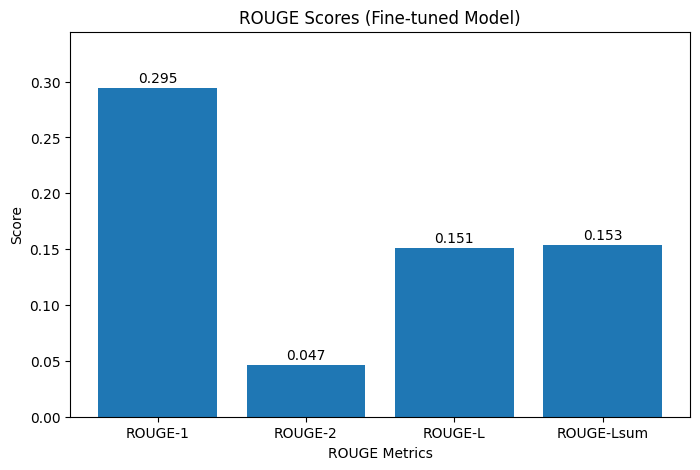

In [20]:
import matplotlib.pyplot as plt

# Use ROUGE results from your code
scores = {
    "ROUGE-1": rouge_scores["rouge1"],
    "ROUGE-2": rouge_scores["rouge2"],
    "ROUGE-L": rouge_scores["rougeL"],
    "ROUGE-Lsum": rouge_scores["rougeLsum"]
}

metrics = list(scores.keys())
values = list(scores.values())

plt.figure(figsize=(8, 5))
plt.bar(metrics, values)

plt.xlabel("ROUGE Metrics")
plt.ylabel("Score")
plt.title("ROUGE Scores (Fine-tuned Model)")
plt.ylim(0, max(values) + 0.05)

for i, v in enumerate(values):
    plt.text(i, v + 0.005, f"{v:.3f}", ha='center')

plt.show()


**BERTScore**

In [13]:
bertscore = evaluate.load("bertscore")
bert_scores = bertscore.compute(
    predictions=preds,
    references=refs,
    lang="en"
)

print("BERTScore F1:", sum(bert_scores["f1"])/len(bert_scores["f1"]))


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BERTScore F1: 0.8392251534864618


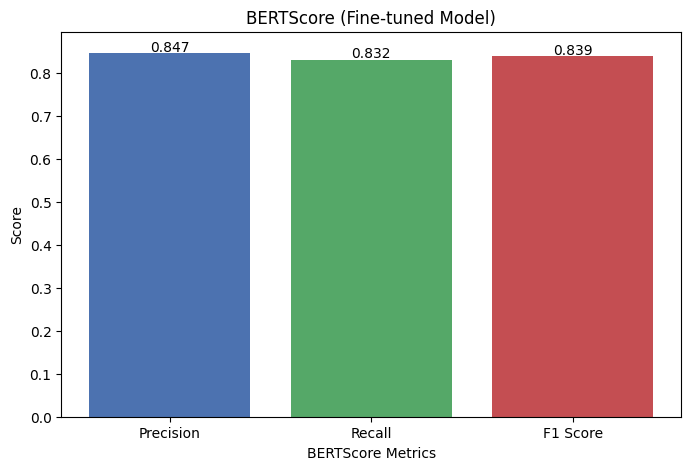

In [24]:
import matplotlib.pyplot as plt

# Extract average precision, recall, F1 from bert_scores
bert_p = sum(bert_scores["precision"]) / len(bert_scores["precision"])
bert_r = sum(bert_scores["recall"]) / len(bert_scores["recall"])
bert_f1 = sum(bert_scores["f1"]) / len(bert_scores["f1"])

metrics = ["Precision", "Recall", "F1 Score"]
values = [bert_p, bert_r, bert_f1]

plt.figure(figsize=(8, 5))
plt.bar(metrics, values, color=["#4C72B0", "#55A868", "#C44E52"])

plt.xlabel("BERTScore Metrics")
plt.ylabel("Score")
plt.title("BERTScore (Fine-tuned Model)")
plt.ylim(0, max(values) + 0.05)

# Add text labels on top of bars
for i, v in enumerate(values):
    plt.text(i, v + 0.005, f"{v:.3f}", ha='center')

plt.show()


**Cosine Similarity**

In [12]:
from sentence_transformers import SentenceTransformer, util

embedder = SentenceTransformer("all-MiniLM-L6-v2")  # small and fast

cos_sims = []

for pred, ref in zip(preds, refs):
    emb1 = embedder.encode(pred, convert_to_tensor=True)
    emb2 = embedder.encode(ref, convert_to_tensor=True)
    cos_sims.append(util.pytorch_cos_sim(emb1, emb2).item())

print("Average Cosine Similarity:", sum(cos_sims)/len(cos_sims))


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Average Cosine Similarity: 0.518726586555069


**BlEu Score**

In [14]:
!pip install sacrebleu


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 4.4 MB/s eta 0:00:00


In [37]:
import sacrebleu

bleu = sacrebleu.corpus_bleu(preds, [refs])   # refs must be list of list
print("BLEU Score:", bleu.score)


BLEU Score: 1.844079392585042
